# 05 — Confronto tra i metodi

Questo notebook **non genera nulla**: legge i file di metriche salvati dai notebook 01–04 e 06 in
`results/metrics/` e costruisce le viste di confronto. Può essere eseguito in qualunque momento,
su qualunque sottoinsieme di risultati già disponibile (i metodi mancanti vengono saltati).

Due viste:
1. **Ambito `sample`, tutti i metodi** — TextRank, LexRank, BART, PEGASUS e PRIMERA valutati
   sullo stesso campione condiviso. Oltre alla media complessiva viene riportata la media sulla
   sola split `test`: è il confronto pulito, perché `google/pegasus-multi_news` e
   `allenai/PRIMERA-multinews` sono stati addestrati sulla split train (leakage, vedi
   notebook 04 e 06).
2. **Ambito `full`, TextRank vs LexRank** — i due estrattivi sull'intero dataset pulito
   (56.101 esempi), con distribuzioni dei punteggi.

⚠️ Nota sui valori assoluti: il ROUGE di pyAutoSummarizer usa insiemi di n-grammi *unici*
(non i conteggi "clipped" del ROUGE ufficiale), quindi i numeri sono confrontabili **tra i metodi
di questo benchmark** ma non direttamente con la letteratura; i valori del paper di Multi-News
sono riportati in fondo solo come contesto qualitativo.

In [1]:
# --- Configurazione ---------------------------------------------------------
import json
from pathlib import Path

import pandas as pd
import summ_utils as su

BASE = su.trova_base_dir()
P = su.percorsi_standard(BASE)
METODI = ['textrank', 'lexrank', 'bart', 'pegasus', 'primera']

# Colori fissi per metodo (palette categorica validata; il colore segue il metodo
# in tutti i grafici, mai la posizione)
COLORI = {'textrank': '#2a78d6', 'lexrank': '#1baf7a',
          'bart': '#eda100', 'pegasus': '#008300', 'primera': '#8250df'}
INK, INK2, MUTED, GRID, SURFACE = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#fcfcfb'

METRICHE_CHIAVE = ['rouge1_f1', 'rouge2_f1', 'rougeL_f1', 'bleu', 'meteor', 'parole_generate']

def carica_scope(scope, metodi):
    """Carica per-esempio (DataFrame) e aggregato (dict) di ogni metodo disponibile.

    Per un confronto equo, i DataFrame vengono ristretti all'INTERSEZIONE dei
    row_id valutati da tutti i metodi caricati (un raro bug della libreria fa
    saltare qualche riga ai metodi estrattivi — vedi README).
    """
    dati = {}
    for metodo in metodi:
        csv_path = P['metrics_dir'] / f'{metodo}_{scope}_per_example.csv'
        json_path = P['metrics_dir'] / f'{metodo}_{scope}_aggregate.json'
        if csv_path.exists() and json_path.exists():
            with open(json_path, encoding='utf-8') as f:
                dati[metodo] = {'df': pd.read_csv(csv_path), 'agg': json.load(f)}
        else:
            print(f'({metodo}/{scope}: metriche non trovate, saltato)')
    if len(dati) > 1:
        comuni = set.intersection(*(set(d['df']['row_id']) for d in dati.values()))
        for d in dati.values():
            d['df'] = d['df'][d['df']['row_id'].isin(comuni)]
        print(f'{scope}: confronto su {len(comuni)} esempi comuni a {len(dati)} metodi')
    return dati

sample_dati = carica_scope('sample', METODI)
full_dati   = carica_scope('full', ['textrank', 'lexrank'])

sample: confronto su 99 esempi comuni a 5 metodi
full: confronto su 55894 esempi comuni a 2 metodi


## Vista 1 — Campione condiviso: tutti i metodi

Medie sul campione completo e sulla sola split `test` (senza leakage). `parole_generate` è la
lunghezza media dei riassunti prodotti — utile per interpretare precisione e recall: i
riferimenti umani sono lunghi in media ~220 parole.

In [2]:
def tabella_medie(dati, solo_split=None):
    righe = {}
    for metodo, d in dati.items():
        df = d['df'] if solo_split is None else d['df'][d['df']['split'] == solo_split]
        if len(df) == 0:
            continue
        righe[metodo] = {**df[METRICHE_CHIAVE].mean().to_dict(), 'n_esempi': len(df)}
    return pd.DataFrame(righe).T.round(4)

if sample_dati:
    print('Medie complessive (campione):')
    display(tabella_medie(sample_dati))
    print("\nMedie sulla sola split 'test' (confronto senza leakage):")
    display(tabella_medie(sample_dati, solo_split='test'))
else:
    print('Nessuna metrica sample disponibile: eseguire prima i notebook 01-04 e 06.')

Medie complessive (campione):


,rouge1_f1,rouge2_f1,rougeL_f1,bleu,meteor,parole_generate,n_esempi
textrank,0.3768,0.1381,0.1758,0.0937,0.4915,359.4444,99.0
lexrank,0.3747,0.1407,0.1734,0.0886,0.5105,436.1010,99.0
bart,0.2605,0.0720,0.1392,0.0157,0.1635,55.6566,99.0
pegasus,0.4710,0.2317,0.2816,0.1754,0.4699,187.0101,99.0
primera,0.4778,0.2312,0.2703,0.1810,0.5057,223.5253,99.0



Medie sulla sola split 'test' (confronto senza leakage):


,rouge1_f1,rouge2_f1,rougeL_f1,bleu,meteor,parole_generate,n_esempi
textrank,0.3944,0.1546,0.1681,0.0982,0.4778,363.750,8.0
lexrank,0.4031,0.1704,0.1830,0.1075,0.5165,435.375,8.0
bart,0.2528,0.0715,0.1225,0.0084,0.1526,58.250,8.0
pegasus,0.4764,0.2560,0.2904,0.2098,0.4749,199.875,8.0
primera,0.4411,0.1997,0.2556,0.1614,0.4827,247.250,8.0


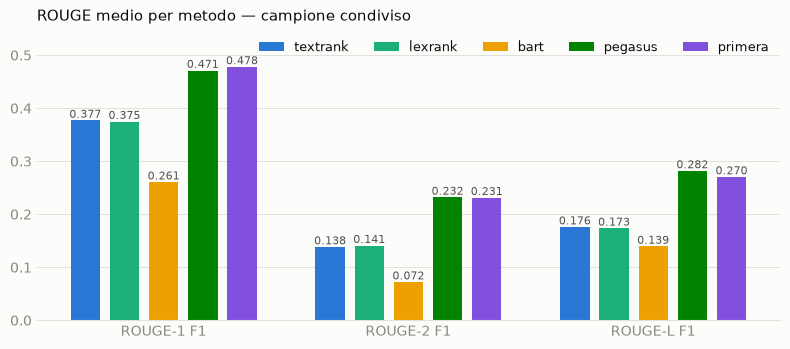

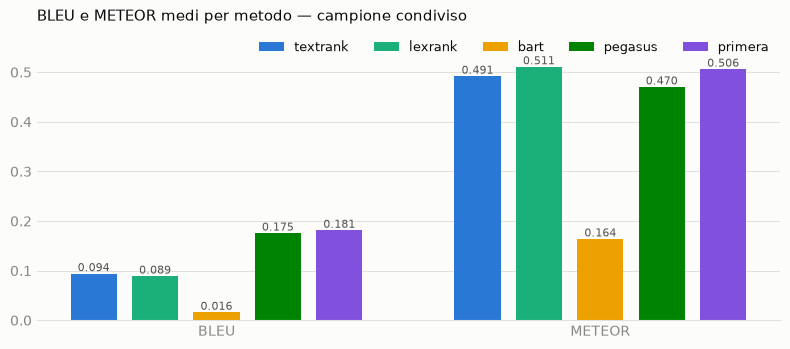

In [3]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({'font.family': 'sans-serif', 'text.color': INK,
                     'axes.edgecolor': GRID, 'axes.labelcolor': INK2,
                     'xtick.color': MUTED, 'ytick.color': MUTED})

def barre_metriche(dati, metriche, etichette, titolo, fmt='{:.3f}'):
    """Barre raggruppate: una tinta fissa per metodo, etichette dirette sui valori."""
    metodi = [m for m in METODI if m in dati]
    fig, ax = plt.subplots(figsize=(8, 3.6), facecolor=SURFACE)
    ax.set_facecolor(SURFACE)
    x, larg = np.arange(len(metriche)), 0.8 / max(len(metodi), 1)
    for j, metodo in enumerate(metodi):
        medie = dati[metodo]['df'][metriche].mean()
        pos = x - 0.4 + larg * (j + 0.5)
        # larghezza ridotta di 0.04 = respiro di ~2px tra barre adiacenti
        ax.bar(pos, medie, larg - 0.04, color=COLORI[metodo], label=metodo, zorder=2)
        for xi, v in zip(pos, medie):
            ax.annotate(fmt.format(v), (xi, v), ha='center', va='bottom',
                        fontsize=8, color=INK2)
    ax.set_xticks(x, etichette)
    ax.set_title(titolo, color=INK, loc='left', fontsize=11)
    ax.grid(axis='y', color=GRID, linewidth=0.7, zorder=0)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.tick_params(length=0)
    ax.legend(frameon=False, ncols=len(metodi), loc='upper right', fontsize=9)
    ax.margins(y=0.15)
    plt.tight_layout()
    plt.show()

if sample_dati:
    barre_metriche(sample_dati, ['rouge1_f1', 'rouge2_f1', 'rougeL_f1'],
                   ['ROUGE-1 F1', 'ROUGE-2 F1', 'ROUGE-L F1'],
                   'ROUGE medio per metodo — campione condiviso')
    barre_metriche(sample_dati, ['bleu', 'meteor'], ['BLEU', 'METEOR'],
                   'BLEU e METEOR medi per metodo — campione condiviso')

## Vista 2 — Intero dataset: TextRank vs LexRank

I due estrattivi confrontati su tutto `complete.tab` (se le corse `SCOPE='full'` dei notebook
01/02 sono state eseguite). Oltre alle medie per split, le distribuzioni complete del ROUGE-1 F1
mostrano quanto i due metodi differiscono esempio per esempio, non solo in media.

Medie complessive (intero dataset):


,rouge1_f1,rouge2_f1,rougeL_f1,bleu,meteor,parole_generate,n_esempi
textrank,0.3683,0.1348,0.1755,0.0887,0.4756,367.3075,55894.0
lexrank,0.3642,0.1369,0.1695,0.0836,0.5022,449.5352,55894.0



textrank — per split:


,n_esempi,rouge1_f1,rouge2_f1,rougeL_f1,bleu,meteor,parole_generate
test,5588.0,0.3697,0.1351,0.1758,0.0883,0.4874,368.0002
train,44714.0,0.3684,0.1348,0.1755,0.0888,0.4730,367.4155
val,5592.0,0.3662,0.1345,0.1750,0.0888,0.4840,365.7516



lexrank — per split:


,n_esempi,rouge1_f1,rouge2_f1,rougeL_f1,bleu,meteor,parole_generate
test,5588.0,0.3651,0.1368,0.1693,0.0829,0.5037,450.1244
train,44714.0,0.3641,0.1369,0.1696,0.0836,0.5021,449.7926
val,5592.0,0.3637,0.1372,0.1690,0.0843,0.5020,446.8879


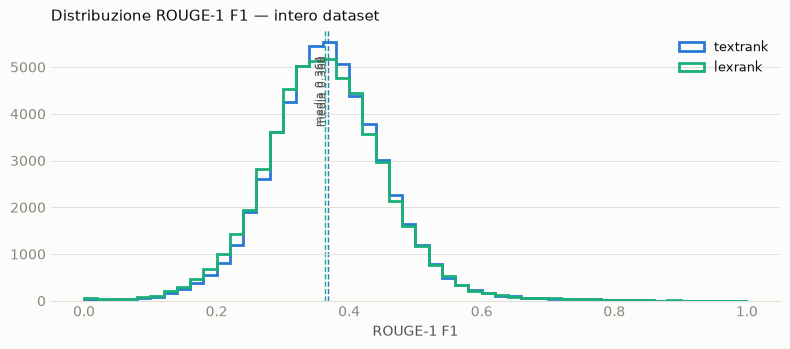

In [4]:
if full_dati:
    print('Medie complessive (intero dataset):')
    display(tabella_medie(full_dati))
    for metodo, d in full_dati.items():
        per_split = d['agg']['per_split']
        print(f"\n{metodo} — per split:")
        display(pd.DataFrame(per_split).T[['n_esempi'] + METRICHE_CHIAVE].round(4))

    # Distribuzione del ROUGE-1 F1: istogrammi a gradini sovrapposti (stessa scala)
    fig, ax = plt.subplots(figsize=(8, 3.6), facecolor=SURFACE)
    ax.set_facecolor(SURFACE)
    bins = np.linspace(0, 1, 51)
    for metodo, d in full_dati.items():
        ax.hist(d['df']['rouge1_f1'], bins=bins, histtype='step', linewidth=2,
                color=COLORI[metodo], label=metodo, zorder=2)
        media = d['df']['rouge1_f1'].mean()
        ax.axvline(media, color=COLORI[metodo], linewidth=1, linestyle='--', zorder=1)
        ax.annotate(f'media {media:.3f}', (media, ax.get_ylim()[1] * 0.9),
                    fontsize=8, color=INK2, rotation=90, va='top', ha='right')
    ax.set_title('Distribuzione ROUGE-1 F1 — intero dataset', color=INK, loc='left', fontsize=11)
    ax.set_xlabel('ROUGE-1 F1')
    ax.grid(axis='y', color=GRID, linewidth=0.7, zorder=0)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.tick_params(length=0)
    ax.legend(frameon=False, fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("Nessuna metrica 'full' disponibile: eseguire i notebook 01/02 con SCOPE='full'.")

## Contesto: i valori del paper originale

Per riferimento qualitativo, il paper di Multi-News (Fabbri et al., 2019, Tabella 6 — split test,
ROUGE ufficiale, input troncato a 500 token) riporta:

| Metodo | R-1 | R-2 | R-SU |
|---|---|---|---|
| TextRank | 38.44 | 13.10 | 13.50 |
| LexRank | 38.27 | 12.70 | 13.20 |
| Hi-MAP (modello del paper) | 43.47 | 14.89 | 17.41 |

**Non sono direttamente confrontabili** con i numeri di questo benchmark: implementazione ROUGE
diversa (n-grammi unici vs conteggi clipped), implementazioni diverse dei metodi estrattivi,
troncamento diverso dell'input e — per l'ambito `sample` — un campione di sole `N_SAMPLES` righe
estratto da tutte e tre le split. Servono solo a collocare l'ordine di grandezza e la gerarchia
attesa tra i metodi.